In [1]:
# environment_version = "6"
# MAGIC %md
# MAGIC # 11 - Model Comparison | Member 1
# MAGIC ## 1. What I am doing
# MAGIC Compare all four completed baselines on the same validation snapshot.
# MAGIC ## 2. Why I am doing it
# MAGIC Accuracy alone can conceal errors on rare crime categories. Rank by macro F1 first,
# MAGIC weighted F1 second, then shorter training time. Inspect convergence and per-class errors too.

## 3. Install notebook libraries
Run on Databricks serverless notebook compute using Python 3.11 or newer.
Dependencies are installed directly in this cell; no separate setup file is needed.
Use the same pinned versions in every Member 4 notebook.
Run the restart cell immediately after installation, then continue with Imports.

%pip install numpy==2.4.6 scipy==1.17.1 scikit-learn==1.9.0 joblib==1.5.3 matplotlib==3.11.0 xgboost==3.4.1
%pip install "pandas<3.0"

In [2]:
if 'dbutils' in globals() and hasattr(dbutils, 'library'):
    dbutils.library.restartPython()


## 4. Imports

In [3]:
from pathlib import Path
import importlib.metadata
import json
import matplotlib.pyplot as plt
import pandas as pd

## 5. Databricks table, artifact location and split configuration
Keep these settings identical in all Member 4 notebooks.
Train: before July 2025; validation: July-December 2025; test: from January 2026.
The first baseline run freezes the clean-table snapshot in a shared volume.
Later notebooks reuse the same data and fitted preprocessing.
Change EXPERIMENT everywhere to intentionally start a new experiment.

In [4]:
CATALOG_SCHEMA = 'workspace.default'
SOURCE_TABLE = f'{CATALOG_SCHEMA}.chicago_crime_clean'
VOLUME_NAME = 'chicago_crime_member4'
ARTIFACT_ROOT = Path(f'/Volumes/workspace/default/{VOLUME_NAME}')
EXPERIMENT = 'member4_v1'
SEED = 42
MAX_LOCAL_ROWS = 750000
TRAIN_END = '2025-07-01'
VALIDATION_END = '2026-01-01'
MODEL_NAMES = ['Logistic_Regression', 'Decision_Tree', 'Random_Forest', 'XGBoost']
RAW_FEATURES = ['date', 'location_description', 'beat', 'district', 'ward', 'community_area', 'latitude', 'longitude', 'domestic']
CATEGORICAL = ['location_description', 'beat', 'district', 'ward', 'community_area', 'area_group']
NUMERIC = ['latitude', 'longitude', 'year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'is_weekend', 'domestic_int', 'coordinates_missing']
LEAKAGE_EXCLUSIONS = ['iucr', 'description', 'fbi_code', 'arrest', 'updated_on', 'case_number']

## 6. Local data and evaluation functions
These cells define the functions used by this notebook. Execute them from top to bottom.
All required code is included here; there are no imports from another project notebook.

In [5]:
def experiment_dir():
    try:
        if ARTIFACT_ROOT.exists() or str(ARTIFACT_ROOT).startswith('/Volumes'):
            exp = ARTIFACT_ROOT / EXPERIMENT
            exp.mkdir(parents=True, exist_ok=True)
            return exp
    except Exception:
        pass
    # Local fallback path
    curr = Path.cwd().resolve()
    for p in [curr] + list(curr.parents):
        if (p / 'databricks').exists():
            exp = p / 'databricks' / 'artifacts' / VOLUME_NAME / EXPERIMENT
            exp.mkdir(parents=True, exist_ok=True)
            return exp
    exp = curr / 'artifacts' / VOLUME_NAME / EXPERIMENT
    exp.mkdir(parents=True, exist_ok=True)
    return exp


In [6]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

In [7]:
def versions():
    return {p: importlib.metadata.version(p) for p in
            ["numpy", "pandas", "scipy", "scikit-learn", "joblib", "matplotlib"]}

In [8]:
def configuration():
    return dict(source_table=SOURCE_TABLE, train_end=TRAIN_END, validation_end=VALIDATION_END,
                seed=SEED, raw_features=RAW_FEATURES, categorical=CATEGORICAL, numeric=NUMERIC,
                preprocessing_version=1)

In [9]:
def load_manifest():
    path = experiment_dir() / "manifest.json"
    if not path.exists():
        raise RuntimeError("Run a baseline notebook (07-10) to prepare the shared data first.")
    manifest = read_json(path)
    if manifest["configuration"] != configuration():
        raise ValueError("Configuration changed. Use a new EXPERIMENT and prepare data again.")
    if manifest["versions"] != versions():
        raise ValueError("Package versions differ from preparation. Use the saved environment versions.")
    return manifest

In [10]:
def comparison(require_all=True):
    manifest = load_manifest()
    rows = []
    for name in MODEL_NAMES:
        path = experiment_dir() / "models" / f"{name}_baseline" / "result.json"
        if not path.exists():
            if require_all:
                raise RuntimeError(f"Run the {name} baseline notebook before comparison/tuning.")
            continue
        result = read_json(path)
        if result["experiment_id"] != manifest["experiment_id"]:
            raise ValueError("Results belong to different data snapshots. Retrain baselines.")
        rows.append(result)
    if not rows:
        raise RuntimeError("No baseline results available.")
    return rank_results(pd.DataFrame(rows))

In [11]:
def rank_results(frame):
    return frame.sort_values(["macro_f1", "weighted_f1", "training_seconds", "model", "tag"],
                             ascending=[False, False, True, True, True]).reset_index(drop=True)

In [12]:
def write_comparison(spark=None):
    table = comparison()
    columns = ["model", "basis", "accuracy", "macro_precision", "macro_recall", "macro_f1",
               "weighted_f1", "train_macro_f1", "training_seconds", "evaluation_seconds", "converged"]
    output = experiment_dir() / "evidence"
    output.mkdir(parents=True, exist_ok=True)
    table[columns].to_csv(output / "model_comparison.csv", index=False)
    if spark is not None:
        (spark.createDataFrame(table[columns].assign(experiment=EXPERIMENT))
         .write.mode("overwrite").option("overwriteSchema", "true")
         .saveAsTable(f"{CATALOG_SCHEMA}.chicago_crime_member4_comparison"))
    return table[columns]

In [13]:
# MEMBER4 EXECUTION CELLS

## 7. Code / analysis
Missing baseline results stop the comparison, preventing an incomplete ranking.
This writes only `workspace.default.chicago_crime_member4_comparison`.

,model,basis,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,train_macro_f1,training_seconds,evaluation_seconds,converged
0,Logistic_Regression,validation,0.364983,0.224034,0.114333,0.116857,0.298342,0.136085,110.983633,0.147215,True
1,XGBoost,validation,0.371395,0.213771,0.117304,0.116356,0.298987,0.175803,127.649720,5.950454,True
2,Decision_Tree,validation,0.342886,0.147988,0.100057,0.099258,0.282611,0.128765,26.613169,0.066168,True
3,Random_Forest,validation,0.349035,0.156105,0.077694,0.070675,0.248752,0.091370,101.938249,1.925212,True


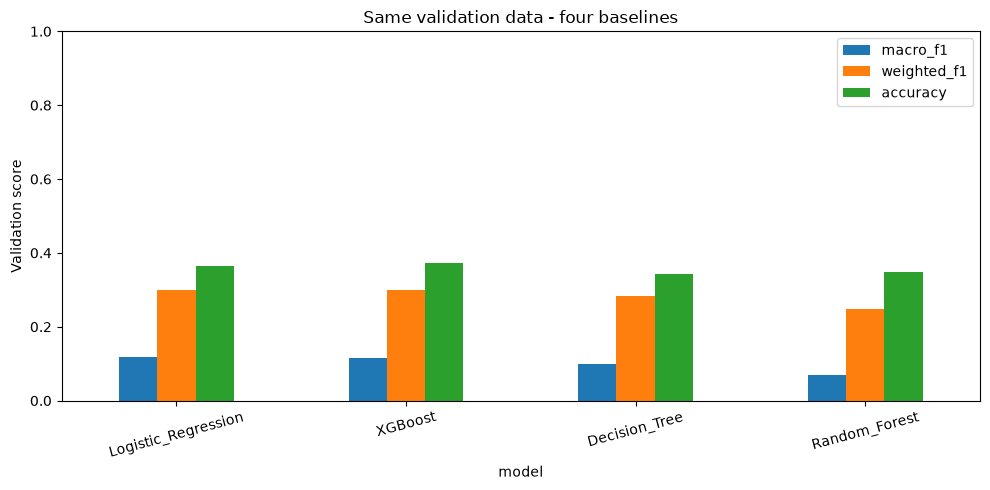

In [14]:
comparison_table = write_comparison()
display(comparison_table)
fig, ax = plt.subplots(figsize=(10, 5))
comparison_table.set_index("model")[["macro_f1", "weighted_f1", "accuracy"]].plot.bar(ax=ax)
ax.set(ylabel="Validation score", ylim=(0, 1), title="Same validation data - four baselines")
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig(experiment_dir() / "evidence" / "model_comparison.png", dpi=150)
display(fig)
plt.close(fig)

In [15]:
for name in MODEL_NAMES:
    directory = experiment_dir() / "models" / f"{name}_baseline"
    print(name)
    print((directory / "findings.txt").read_text(encoding="utf-8"))
    display(pd.read_csv(directory / "validation_per_class.csv").sort_values("support").head(10))

Logistic_Regression
Strongest supported class: BATTERY (F1=0.541).
Weakest supported class: ARSON (F1=0.000, support=182).
Largest error pair: CRIMINAL DAMAGE predicted as THEFT (6113 rows).
Compare macro and weighted F1: common classes can conceal weak rare-class performance.


,primary_type,precision,recall,f1,support
18,NON-CRIMINAL,0.000000,0.000000,0.000000,0
24,PUBLIC INDECENCY,0.000000,0.000000,0.000000,3
21,OTHER NARCOTIC VIOLATION,0.000000,0.000000,0.000000,4
9,GAMBLING,0.000000,0.000000,0.000000,7
11,HUMAN TRAFFICKING,0.000000,0.000000,0.000000,8
19,OBSCENITY,0.000000,0.000000,0.000000,28
14,KIDNAPPING,0.000000,0.000000,0.000000,40
13,INTIMIDATION,0.000000,0.000000,0.000000,87
15,LIQUOR LAW VIOLATION,0.166667,0.060000,0.088235,100
4,CONCEALED CARRY LICENSE VIOLATION,0.177778,0.069565,0.100000,115


Decision_Tree
Strongest supported class: PROSTITUTION (F1=0.573).
Weakest supported class: ARSON (F1=0.000, support=182).
Largest error pair: CRIMINAL DAMAGE predicted as THEFT (6307 rows).
Compare macro and weighted F1: common classes can conceal weak rare-class performance.


,primary_type,precision,recall,f1,support
18,NON-CRIMINAL,0.0,0.0,0.0,0
24,PUBLIC INDECENCY,0.0,0.0,0.0,3
21,OTHER NARCOTIC VIOLATION,0.0,0.0,0.0,4
9,GAMBLING,0.0,0.0,0.0,7
11,HUMAN TRAFFICKING,0.0,0.0,0.0,8
19,OBSCENITY,0.0,0.0,0.0,28
14,KIDNAPPING,0.0,0.0,0.0,40
13,INTIMIDATION,0.0,0.0,0.0,87
15,LIQUOR LAW VIOLATION,0.0,0.0,0.0,100
4,CONCEALED CARRY LICENSE VIOLATION,0.0,0.0,0.0,115


Random_Forest
Strongest supported class: BATTERY (F1=0.514).
Weakest supported class: ARSON (F1=0.000, support=182).
Largest error pair: CRIMINAL DAMAGE predicted as THEFT (8514 rows).
Compare macro and weighted F1: common classes can conceal weak rare-class performance.


,primary_type,precision,recall,f1,support
18,NON-CRIMINAL,0.0,0.0,0.0,0
24,PUBLIC INDECENCY,0.0,0.0,0.0,3
21,OTHER NARCOTIC VIOLATION,0.0,0.0,0.0,4
9,GAMBLING,0.0,0.0,0.0,7
11,HUMAN TRAFFICKING,0.0,0.0,0.0,8
19,OBSCENITY,0.0,0.0,0.0,28
14,KIDNAPPING,0.0,0.0,0.0,40
13,INTIMIDATION,0.0,0.0,0.0,87
15,LIQUOR LAW VIOLATION,0.0,0.0,0.0,100
4,CONCEALED CARRY LICENSE VIOLATION,0.0,0.0,0.0,115


XGBoost
Strongest supported class: BATTERY (F1=0.543).
Weakest supported class: ARSON (F1=0.000, support=182).
Largest error pair: CRIMINAL DAMAGE predicted as THEFT (6275 rows).
Compare macro and weighted F1: common classes can conceal weak rare-class performance.


,primary_type,precision,recall,f1,support
18,NON-CRIMINAL,0.000000,0.000000,0.000000,0
24,PUBLIC INDECENCY,0.000000,0.000000,0.000000,3
21,OTHER NARCOTIC VIOLATION,0.000000,0.000000,0.000000,4
9,GAMBLING,0.000000,0.000000,0.000000,7
11,HUMAN TRAFFICKING,0.000000,0.000000,0.000000,8
19,OBSCENITY,0.000000,0.000000,0.000000,28
14,KIDNAPPING,0.000000,0.000000,0.000000,40
13,INTIMIDATION,0.000000,0.000000,0.000000,87
15,LIQUOR LAW VIOLATION,0.311111,0.140000,0.193103,100
4,CONCEALED CARRY LICENSE VIOLATION,0.224490,0.095652,0.134146,115


## 8. Findings / conclusion
Review whether the macro-F1 leader also has acceptable rare-class recall and runtime.
The two leading converged candidates are tuned in folder 12. Final recommendation follows tuning.
Validation performance is selection evidence; it is not an unbiased final test estimate.